In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import pbn_37k
from pbn_37k.ask import sigAssistant

import pandas as pd
from tqdm import tqdm
tqdm.pandas()

from dotenv import load_dotenv
load_dotenv()

brain = sigAssistant(pathCache=".cache/", llm_highend="gpt-4o",  llm_fast="gpt-4o-mini")

In [9]:
with open("data/cities/prompt/prompt.md", "r") as f:
    prompt_template = f.read()
with open("data/cities/activities.md", "r") as f:
    prompt_activity = f.read()
with open("data/cities/portfolio.md", "r") as f:
    prompt_portfolio = f.read()
with open("data/cities/prompt/cities.md", "r") as f:
    cities = [x.strip("*").strip() for x in f.read().split("\n") ]
cn = ["gotham", "baraddur", "kingslanding", "coruscant", "wakanda", "shire", "capitol"]

In [10]:
HEADER = """---
layout: default
title: TITLE
parent: PARENT
has_children: true
nav_order: NAVORDER
---\n\n"""

In [11]:
CITIES = {}
for i in range(len(cities)):
    desc = cities[i]
    q = prompt_template.replace("$CITYNAME$", desc)
    urban_report = brain.ask(q)
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    report = HEADER.replace("TITLE", cn[i].title()).replace("NAVORDER", str(i+3)).replace("\nparent: PARENT","") + urban_report
    report = report.replace("## **Overview & Sustainability Profile**","## Overview & Sustainability Profile")
    report = report.replace("## Overview & Sustainability Profile","## Assessment\n\n![](images/"+cn[i]+"_review.png)\n\n## Overview & Sustainability Profile")


    CITIES[cn[i]] = {"report": report}
    
    with open(f"docs/{cn[i]}_report.md", "w") as f:
        f.write(report)

--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56
--- gpt-4o-mini:	 2025-10-23 09:50:56


In [ ]:
for i in range(len(cities)):
    desc = CITIES[cn[i]]["report"]
    q = prompt_portfolio.replace("DESCRIPTION", desc)
    urban_report = brain.ask(q)

    analysis = brain.analyseText( txt=urban_report,
                TypeOfItem = "Vision",
                Source="maptivity.online",
                Place=cn[i].title(),
                MIN=15,
                Reviewed=True,
                MODEL="gpt-4o-mini")
    
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    report = HEADER.replace("TITLE", cn[i].title()+"'s portfolio").replace("NAVORDER", str(i+1)).replace("PARENT",cn[i].title()) + urban_report
    CITIES[cn[i]]["portfolio"] = {"portfolio": report}
    with open(f"docs/{cn[i]}_portfolio.md", "w") as f:
        f.write(report)

    for k in range(7):
        q = prompt_activity.replace("$$DESC$$", desc).replace("$$ACT$$", urban_report)
        q = q.replace("$$NN$$ ", str(k+1))
        activity_report = brain.ask(q)


        analysis = brain.analyseText( txt=activity_report,
                        TypeOfItem = "Activity",
                        Source="maptivity.online",
                        Place=cn[i].title(),
                        MIN=7,
                        Reviewed=False,
                        MODEL="gpt-4o-mini")

        reportB = activity_report
        CITIES[cn[i]]["portfolio"][f"activity_{k+1}"] = reportB

        SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"

        reportB = reportB.replace("## **CONTEXTUAL FOUNDATION**",SCORE + "## **CONTEXTUAL FOUNDATION**")
        shorttitle = reportB.split("###")[1].split("\n")[1].replace("**","").split(":")[0].strip()
        print(cn[i], k+1, shorttitle)
        reportB = HEADER.replace("TITLE", shorttitle).replace("NAVORDER", str(k+2)).replace("PARENT",cn[i].title()) + reportB
        reportB = reportB.replace("has_children: true _n","")


        with open(f"docs/{cn[i]}_activity_{k+1}.md", "w") as f:
            f.write(reportB)


    


--- gpt-4o-mini:	 2025-10-23 09:58:47
Old MIN: 15
New MIN: 5
--- Function call:	 2025-10-23 09:58:57
--- gpt-4o-mini:	 2025-10-23 09:58:58
--- gpt-4o-mini:	 2025-10-23 09:58:59
--- gpt-4o-mini:	 2025-10-23 09:58:59
--- gpt-4o-mini:	 2025-10-23 09:59:00
--- gpt-4o-mini:	 2025-10-23 09:59:00
--- gpt-4o-mini:	 2025-10-23 09:59:01
--- gpt-4o-mini:	 2025-10-23 09:59:02
--- gpt-4o-mini:	 2025-10-23 09:59:03
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
--- gpt-4o-mini:	 2025-10-23 09:59:04
Good du premier coup, length 10 vs MIN of 5
--- gpt-4o-mini:	 2025-10-23 09:59:04
Already done
gotham 1 Gotham Greenway Revival
--- gpt-4o-

# Reviews

In [ ]:
import pbn_37k.img as iImg
from pbn_37k.reportmgr import createExcel

df = brain.getMemory()
print(len(df))
df.head(2)

487


,FromProbono,Origin,Place,Type,Source,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed,model,timestamp,reviewsrc
0,False,maptivity.online,Gotham,Activity,## **PROJECT IDENTIFICATION**\n\n### **Project...,The Gotham Greenway Initiative emphasizes the ...,Attractiveness,Culture and community identity,Neighbourhood,5,Green corridors enhance Gotham's identity.,Gotham Greenway Initiative enhances urban envi...,False,gpt-4o-mini,"10/23/2025, 09:05:49",N/A
1,False,maptivity.online,Gotham,Activity,## **PROJECT IDENTIFICATION**\n\n### **Project...,This initiative focuses on implementing green ...,Preservation and improvement of environment,Biodiversity and ecosystem services,Neighbourhood,5,Green infrastructure enhances urban ecosystems.,Gotham Greenway Initiative enhances urban envi...,False,gpt-4o-mini,"10/23/2025, 09:05:49",N/A


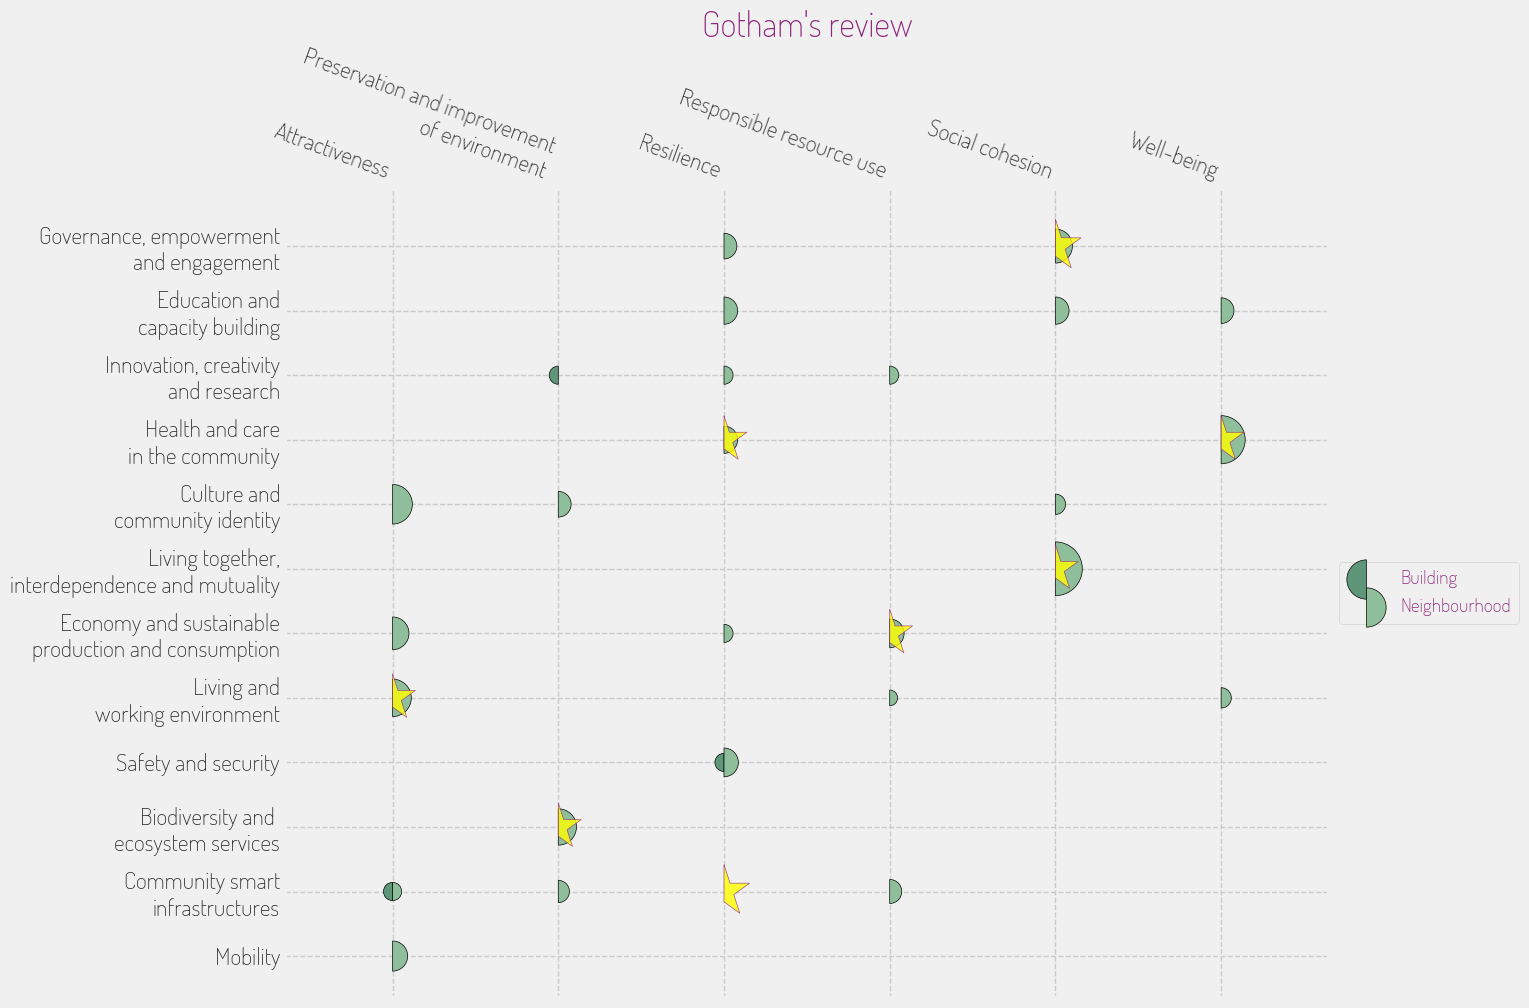

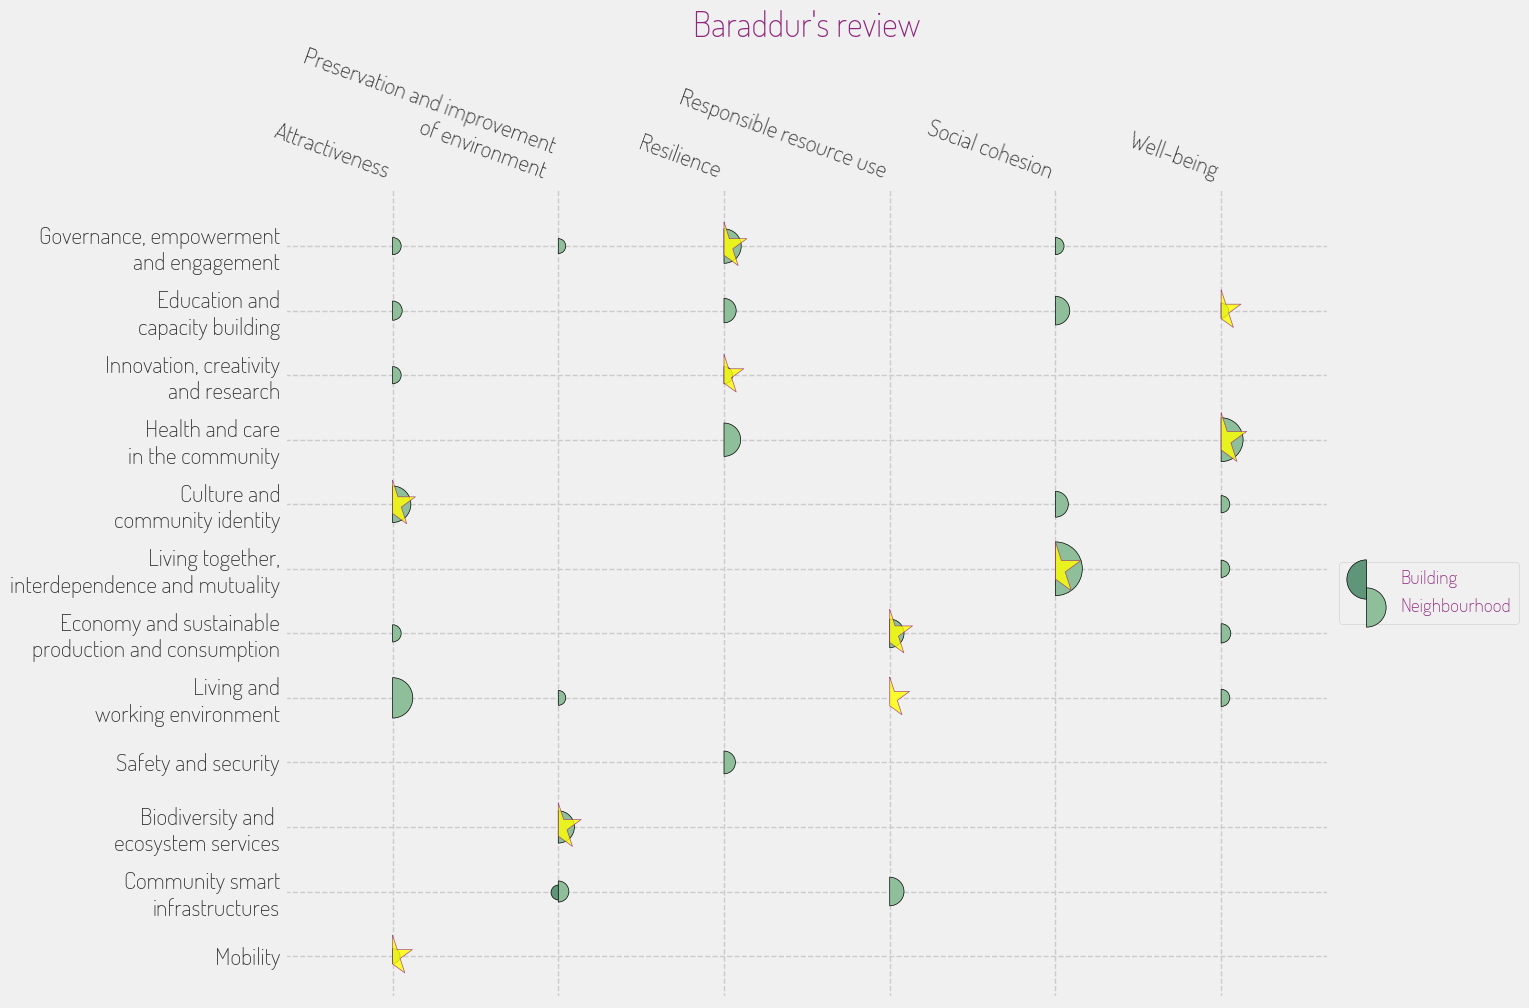

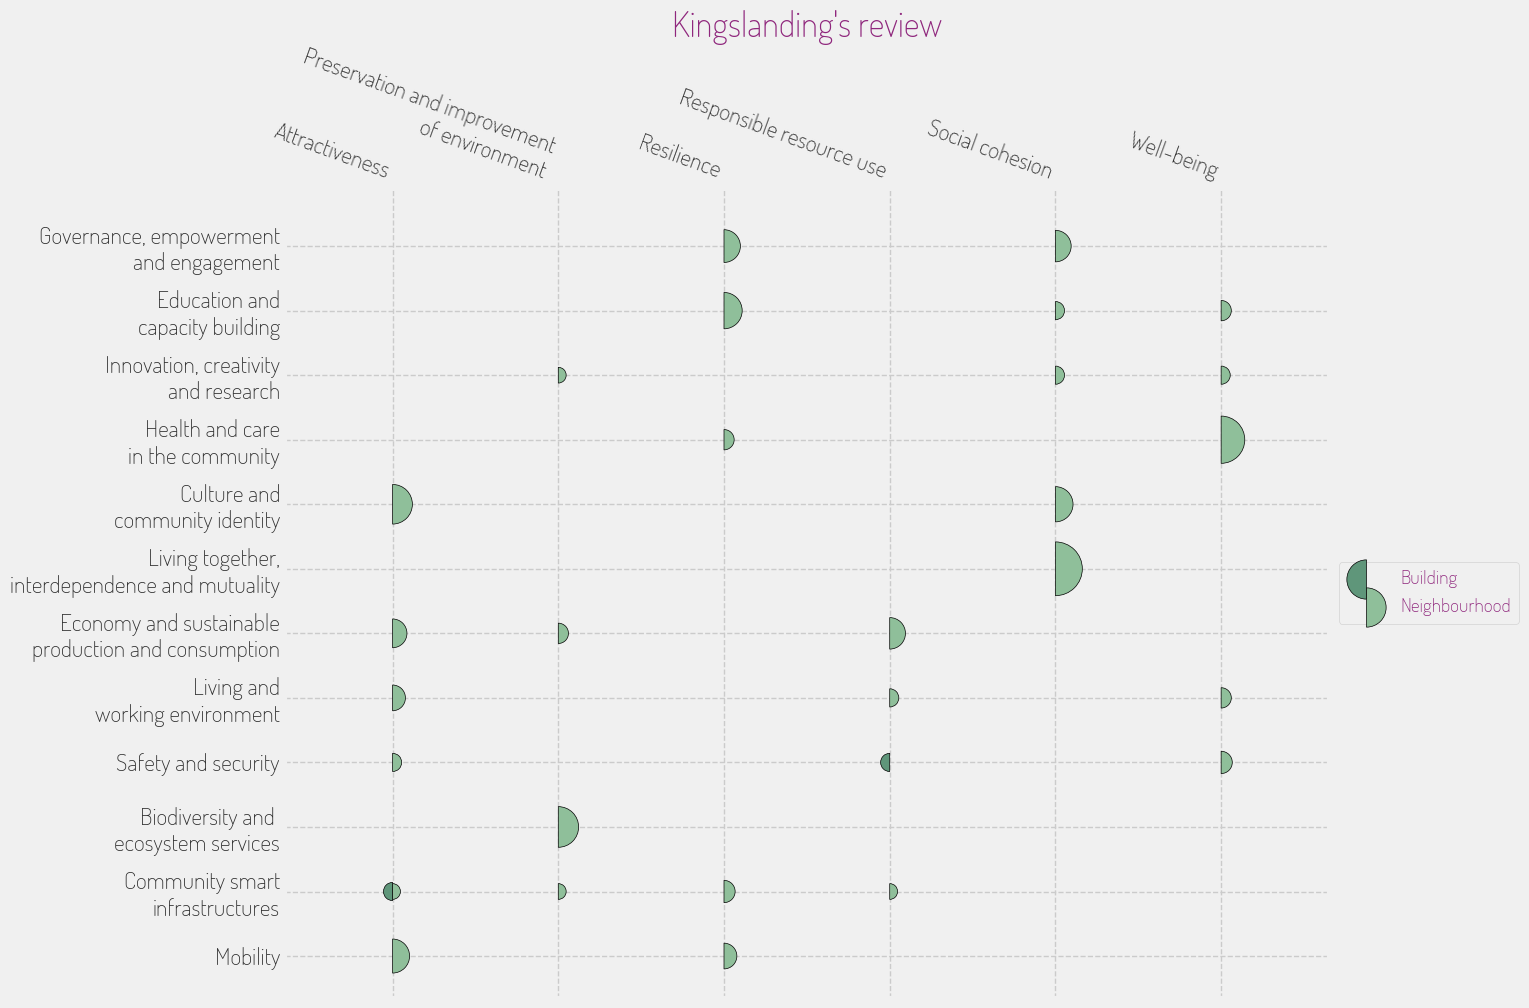

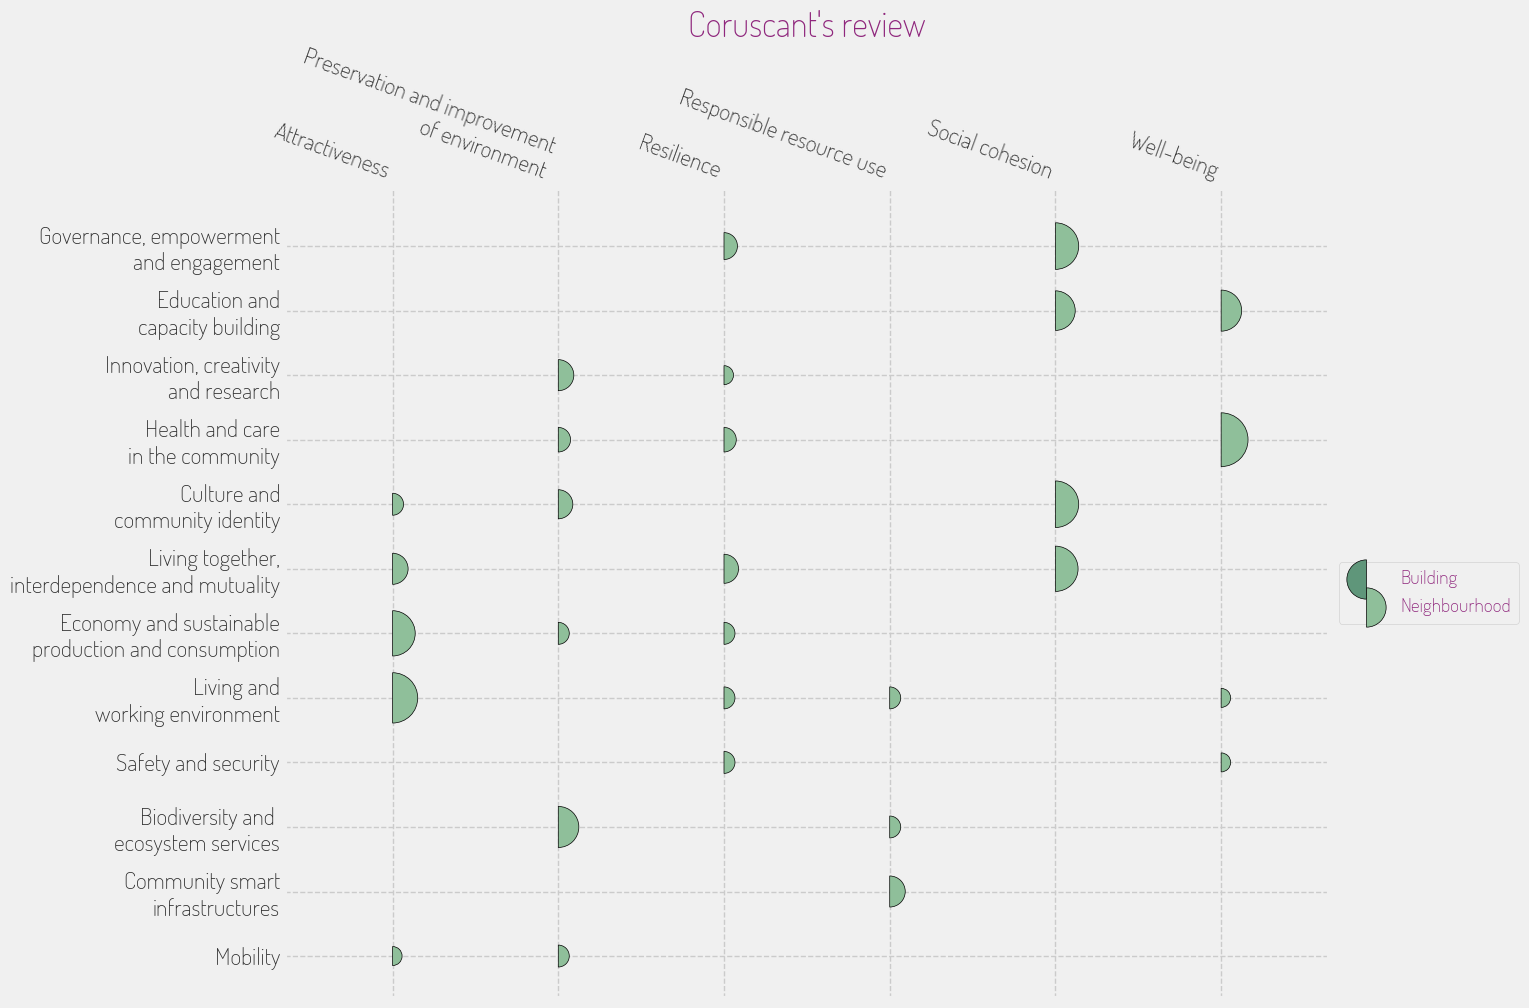

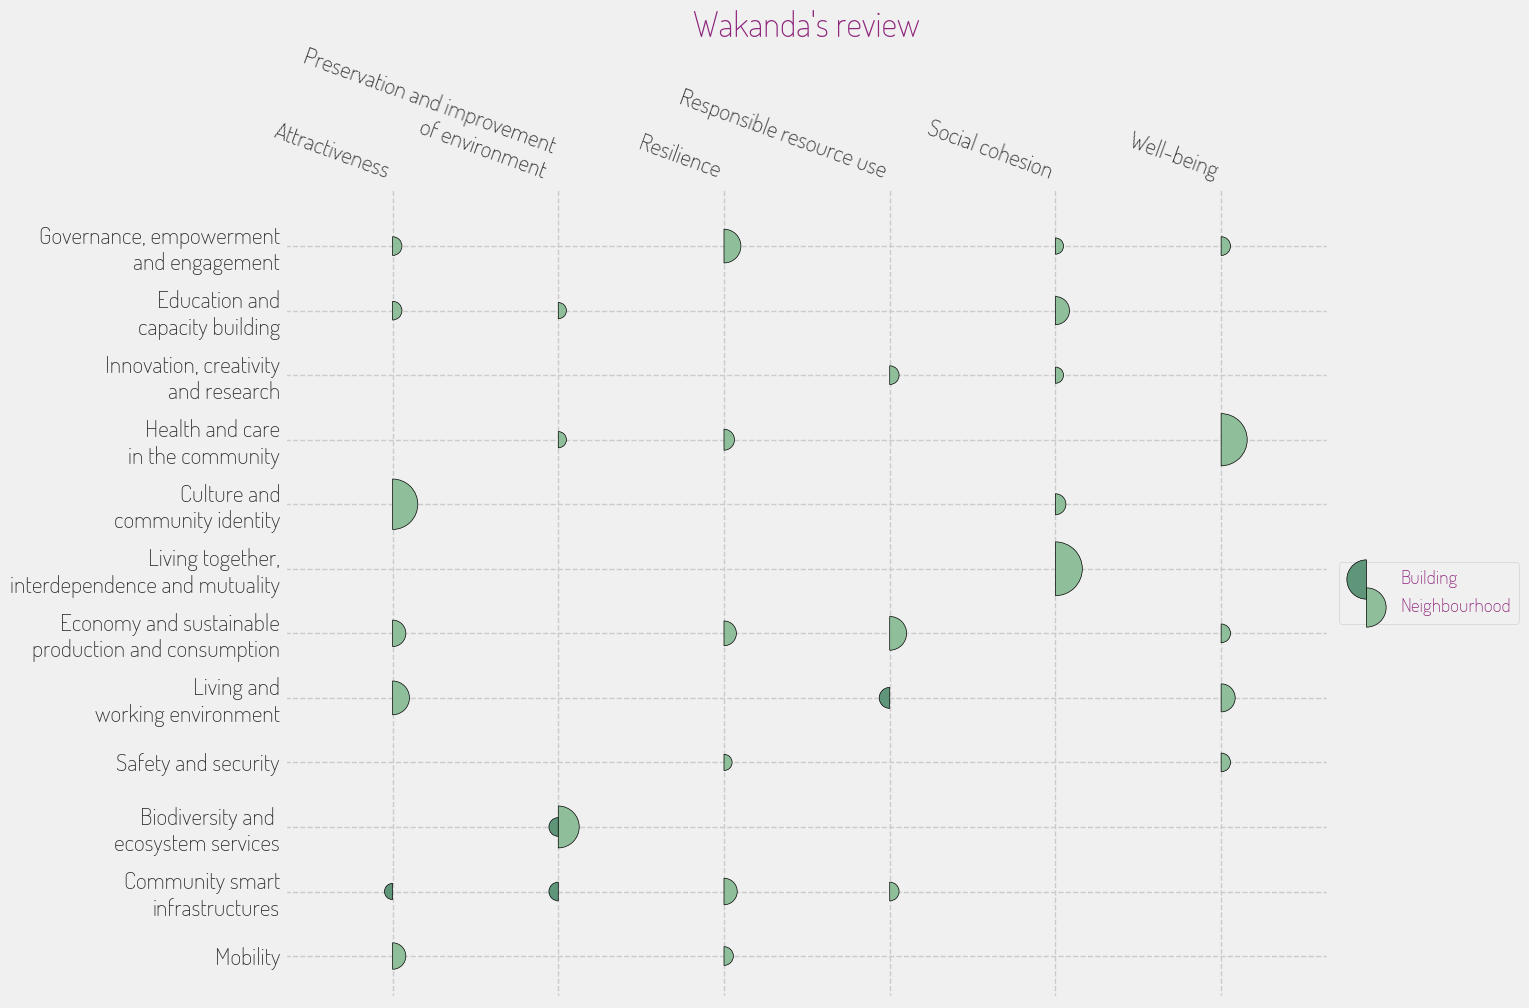

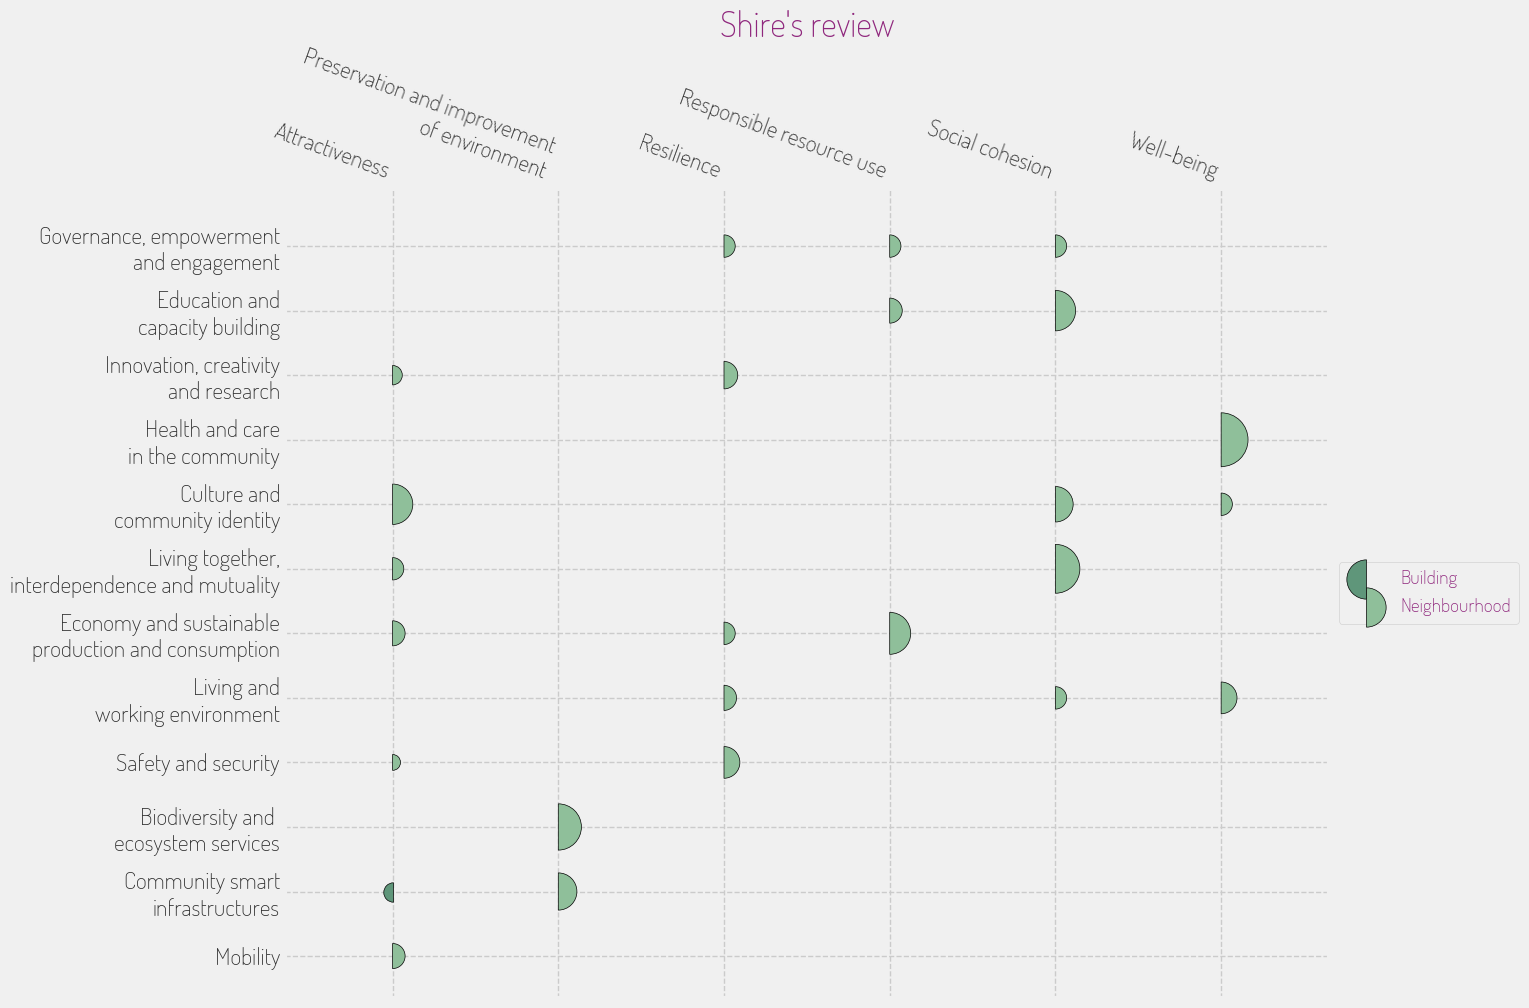

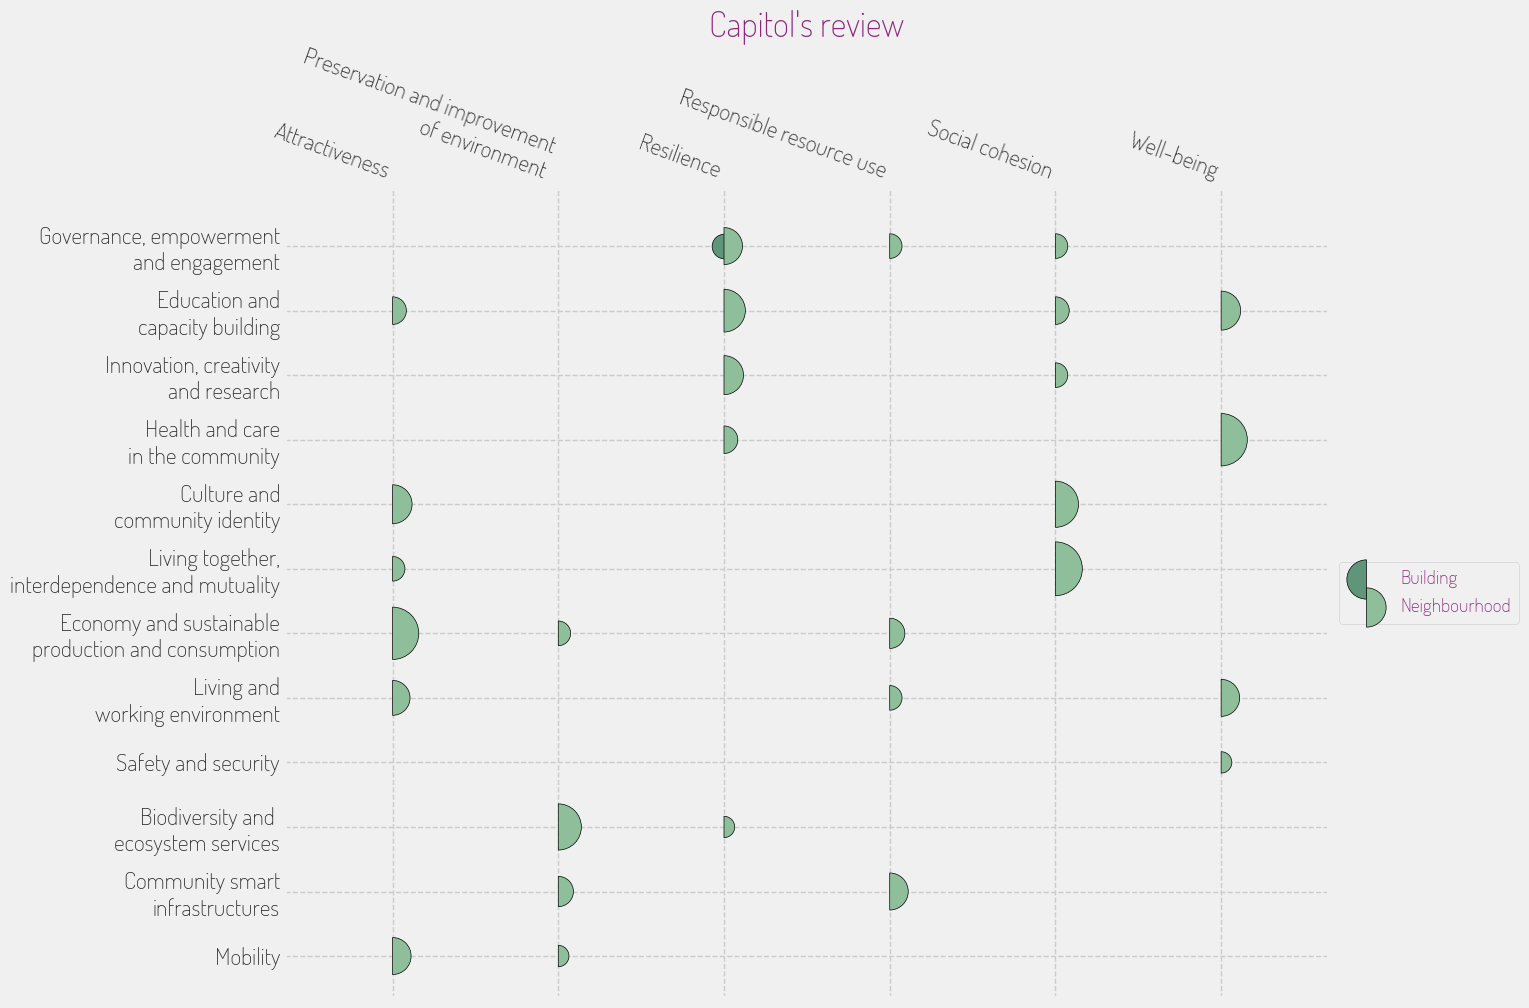

In [ ]:
for place in df.Place.unique():
    D = df[df.Place == place]
    dfRef = D[D.Type == "Vision"]
    dfRef = dfRef[dfRef.Reviewed == True]
    dfUC  = D[D.Type == "Activity"]
    plt, ax = iImg.createImg(dfUC, dfRef, title=place+"'s review")
    plt.savefig(f"docs/images/{place.lower()}_review.png", bbox_inches="tight")

In [ ]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
